# Homogeneous Square Domain

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import pu239, research_reactor
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig
from ttnte.cad import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Vacuum Boundary Conditions
### Define cross section library and IGA mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = pu239(num_groups=2)

In [3]:
# Create NURBS geometry
length = 6.5 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patch = Patch(cad.bilinear(points), "Pu-239")

# Create mesh
mesh = IGAMesh()
mesh.add_patch(patch)

# Refine mesh resolution
mesh.refine(factor=10, degree=3)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Pu-239, source=None, id=0, name=None, shape=(13, 13), backend=geomdl)

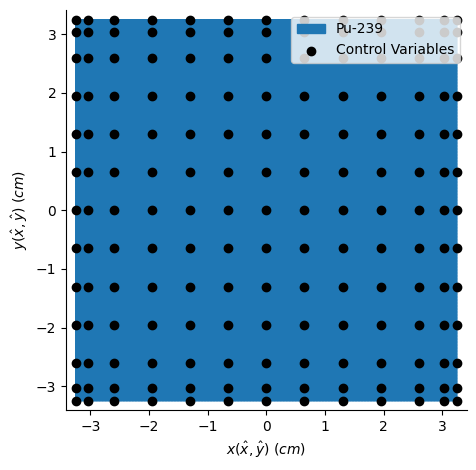

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square_vac.png", dpi=300)
plt.show()

### Assemble TT operators

In [5]:
# Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_info("./tt_info_vac.csv")

Running TTAssembler.build()
Discretization: N = 1024, G = 2, P = 1, A = 13, B = 13
Operators: H, S, F, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 7.63 s)
Step            Ranks                     Compression
H               3,3,3,3,2                 19820237.68
S               1,1,1,1,1                 137693697.18
F               1,1,1,1,1                 137693697.18
B_out           3,4,4,4,3                 12205146.87


### Solve

In [6]:
k, psi = eig(
    LHS=LinearOperator([tts.H, tts.B_out, -tts.S], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([tts.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Save solution
mesh.save(path="mesh_vac.hdf5", solution=psi.unsqueeze(4), k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Starting power iteration


-- (0): k = 0.94088667, Angular Flux L2-Error = 0.58017077, Elapsed Time = 1.69


-- (1): k = 0.97956642, Angular Flux L2-Error = 0.12623772, Elapsed Time = 3.274


-- (2): k = 0.99157738, Angular Flux L2-Error = 0.04148378, Elapsed Time = 4.867


-- (3): k = 0.99562239, Angular Flux L2-Error = 0.01468513, Elapsed Time = 6.452


...

-- (14): k = 0.99784436, Angular Flux L2-Error = 2.8e-07, Elapsed Time = 23.925


-- (15): k = 0.99784439, Angular Flux L2-Error = 1.2e-07, Elapsed Time = 25.513


-- (16): k = 0.99784439, Angular Flux L2-Error = 7e-08, Elapsed Time = 27.101


-- (17): k = 0.9978444, Angular Flux L2-Error = 4e-08, Elapsed Time = 28.688


-- (18): k = 0.9978444, Angular Flux L2-Error = 1e-08, Elapsed Time = 29.259
-- Converged: k = 0.9978444, Elapsed Time = 29.259


### Plotting and comparison to OpenMC

In [7]:
# Get OpenMC solution
k_mc = [0.997955, 0.000031]
phi_mc = np.load("./openmc/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: -11.060097675263947 +/- 3.1e-05 pcm


<Figure size 640x480 with 0 Axes>

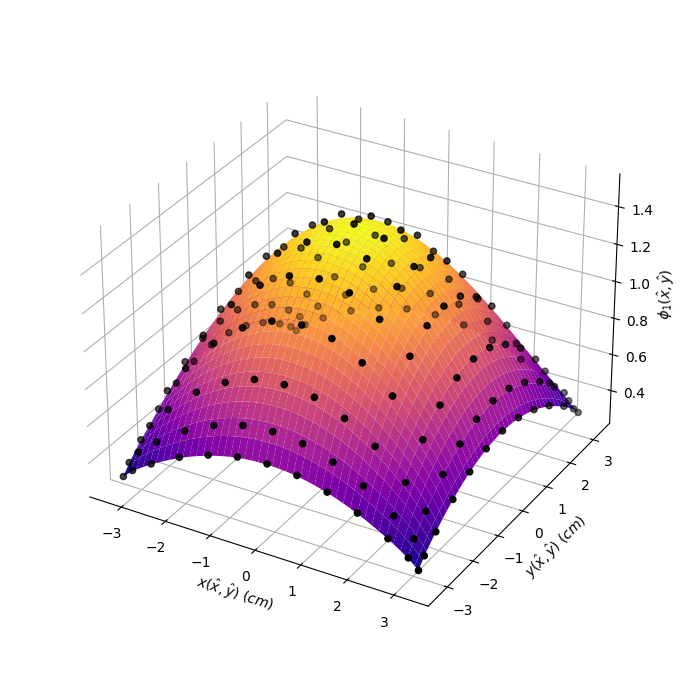

<Figure size 640x480 with 0 Axes>

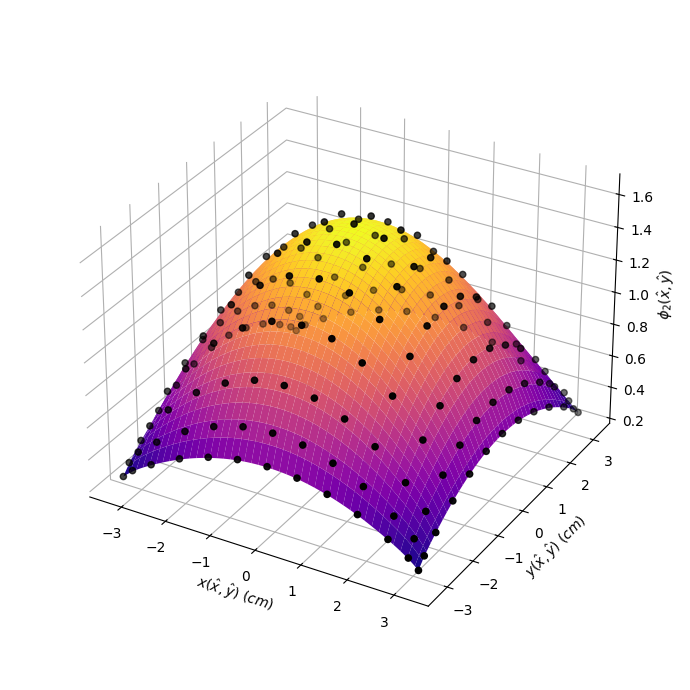

In [8]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, length, phi_mc.shape[1]),
    np.linspace(0, length, phi_mc.shape[2]),
)

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_3d=True, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_vac.png", dpi=300)
    plt.show()

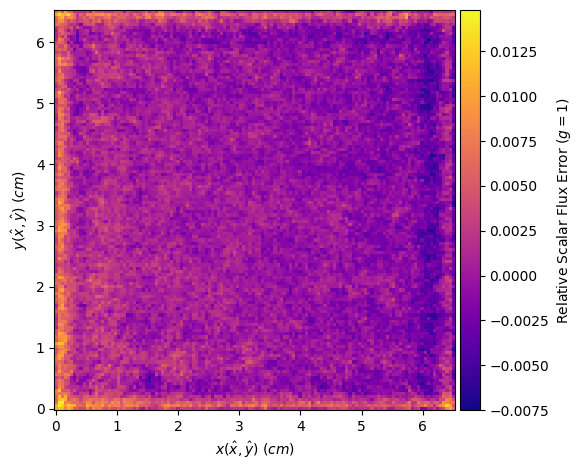

Scalar flux Relative L2-error (g = 1): 0.0017569647157513024


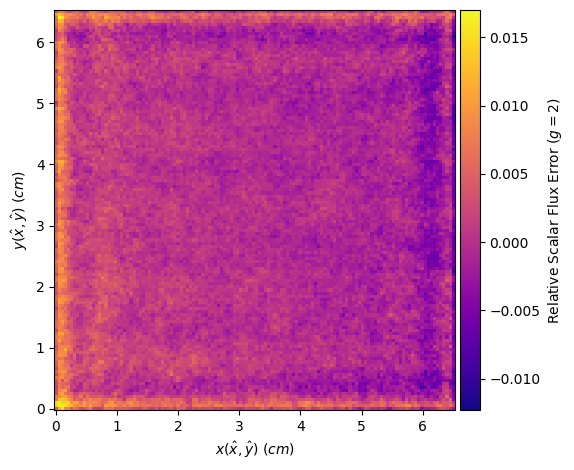

Scalar flux Relative L2-error (g = 2): 0.0018349873924276092
Total scalar flux Relative L2-error: 0.0017989972103702049


In [9]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

for g in range(xs_server.num_groups):    
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(
        X, Y, (phi_mc[g,] - phi_avg[g,]) / phi_mc[g,], cmap="plasma"
    )
    divider = make_axes_locatable(ax)

    plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
        label=f"Relative Scalar Flux Error ($g = {g + 1}$)",
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi{g + 1}_vac_error.png", dpi=300)
    plt.show()
    
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)

## Reflective Boundary Conditions

### Build IGA mesh

In [10]:
# Create NURBS geometry
length = 3.591204 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))

# Create mesh
mesh = IGAMesh()
mesh.add_patch(Patch(cad.bilinear(points), "Pu-239"))

# Refine mesh resolution
mesh.refine(factor=[3, 7], degree=4)

# Connect mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("top", "bottom"))

# Finalize patches
mesh.finalize()
mesh

IGAMesh(id=1, name=None, num_patches=1, reflective_boundaries=True)
  -> Patch(material=Pu-239, source=None, id=1, name=None, shape=(7, 11), backend=geomdl)

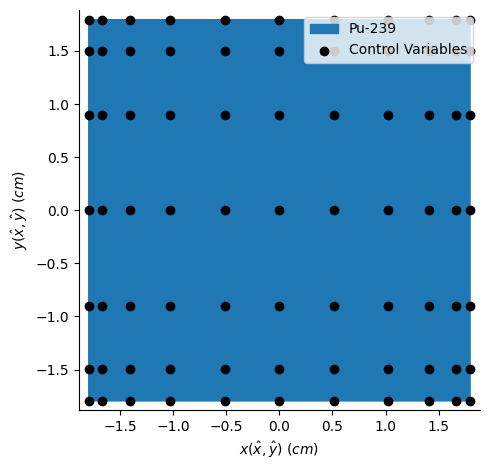

In [11]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square_ref.png", dpi=300)
plt.show()

### Assemble TT operators

In [12]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_info("./tt_info_ref.csv")

Running TTAssembler.build()
Discretization: N = 1024, G = 2, P = 1, A = 7, B = 11
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 5.63 s)
Step            Ranks                     Compression
H               3,3,3,3,2                 4756700.16
S               1,1,1,1,1                 35424541.90
F               1,1,1,1,1                 35424541.90
B_out           3,4,4,4,3                 3021264.54
B_in            2,2,2,2,1                 10742128.91


### Solve and check eigenvalue

In [13]:
k, psi = eig(
    LHS=LinearOperator([tts.H, tts.B_out, -tts.S, -tts.B_in], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([tts.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Save solution
mesh.save(path="mesh_ref.hdf5", solution=psi.unsqueeze(4), k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

# Calculate eigenvalue error
print("keff error: {} pcm".format((k - 1) * 1e5))

Starting power iteration


-- (0): k = 0.98268535, Angular Flux L2-Error = 0.56328998, Elapsed Time = 1.39


-- (1): k = 0.99635349, Angular Flux L2-Error = 0.05390381, Elapsed Time = 2.765


-- (2): k = 0.9988636, Angular Flux L2-Error = 0.01082176, Elapsed Time = 4.144


-- (3): k = 0.99937131, Angular Flux L2-Error = 0.00230919, Elapsed Time = 5.52


...

-- (63): k = 0.99950722, Angular Flux L2-Error = 2e-08, Elapsed Time = 88.022


-- (64): k = 0.99950722, Angular Flux L2-Error = 2e-08, Elapsed Time = 89.39


-- (65): k = 0.99950722, Angular Flux L2-Error = 1e-08, Elapsed Time = 90.762


-- (66): k = 0.99950722, Angular Flux L2-Error = 1e-08, Elapsed Time = 92.132


-- (67): k = 0.99950722, Angular Flux L2-Error = 1e-08, Elapsed Time = 93.498
-- (68): k = 0.99950722, Angular Flux L2-Error = 0.0, Elapsed Time = 93.582
-- Converged: k = 0.99950722, Elapsed Time = 93.582
keff error: -49.27805742007685 pcm


### Plot solution

<Figure size 640x480 with 0 Axes>

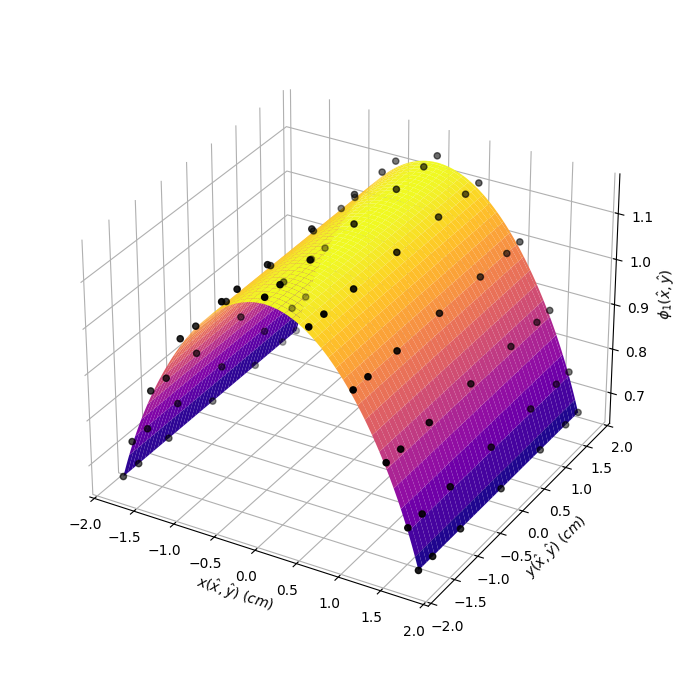

<Figure size 640x480 with 0 Axes>

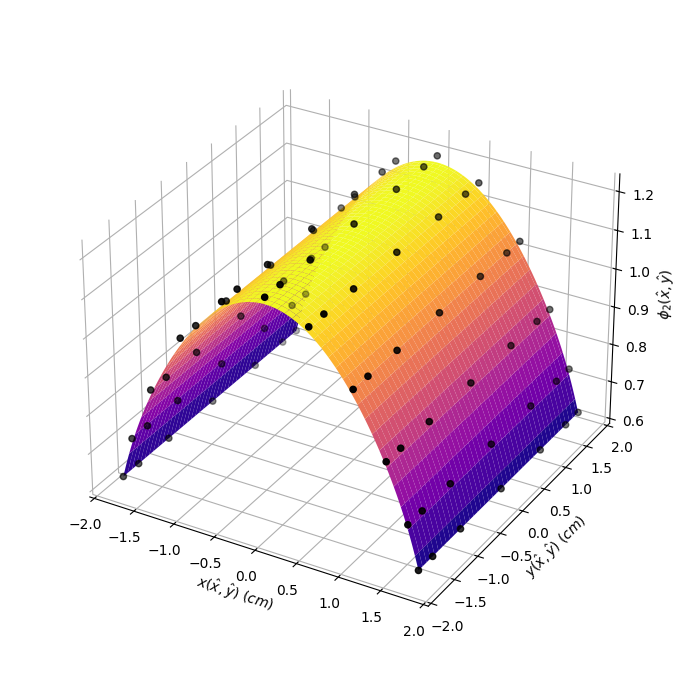

In [14]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_3d=True, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_ref.png", dpi=300)
    plt.show()

## Linearly Anisotropic

### Define cross section library and IGA mesh

In [15]:
# Get XS data
xs_server = research_reactor(is_anisotropic=True)

# Create NURBS geometry
length = 9.4959 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))

# Create mesh
mesh = IGAMesh()
mesh.add_patch(Patch(cad.bilinear(points), "Research Reactor"))

# Refine mesh resolution
mesh.refine(factor=[5, 7], degree=3)

# Connect patches
mesh.connect()

# Define boundary conditions
mesh.set_reflective_conditions(("left", "top", "bottom"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=2, name=None, num_patches=1, reflective_boundaries=True)
  -> Patch(material=Research Reactor, source=None, id=2, name=None, shape=(8, 10), backend=geomdl)

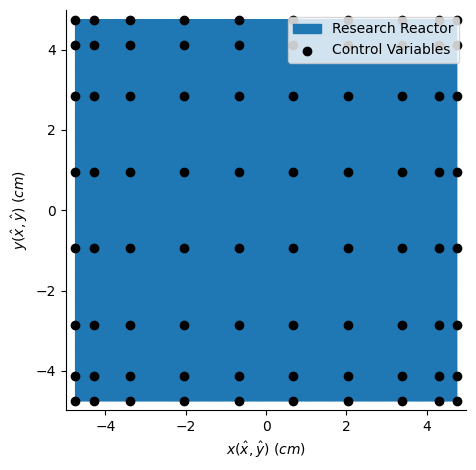

In [16]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square_anisotropic.png", dpi=300)
plt.show()

### Assemble TT operators

In [17]:
# Initialize builder
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_info("./tt_info_anisotropic.csv")

Running TTAssembler.build()
Discretization: N = 1024, G = 2, P = 1, A = 8, B = 10
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 4.11 s)
Step            Ranks                     Compression
H               3,3,3,3,2                 5087859.29
S               3,3,2,1,1                 6611710.74
F               1,1,1,1,1                 38568312.64
B_out           3,4,4,4,3                 3215566.08
B_in            3,3,3,3,2                 5087859.29


### Solve

In [18]:
k, psi = eig(
    LHS=LinearOperator([tts.H, tts.B_out, -tts.S, -tts.B_in], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([tts.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
)

# Save solution
mesh.save(path="mesh_anisotropic.hdf5", solution=psi.unsqueeze(4), k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

# Calculate eigenvalue error
print("keff error: {} pcm".format((k - 1) * 1e5))

Starting power iteration


-- (0): k = 0.9043517, Angular Flux L2-Error = 1.21615946, Elapsed Time = 1.389


-- (1): k = 0.98619096, Angular Flux L2-Error = 0.1402703, Elapsed Time = 2.768


-- (2): k = 0.99748486, Angular Flux L2-Error = 0.02174288, Elapsed Time = 4.149


-- (3): k = 0.99949277, Angular Flux L2-Error = 0.00405318, Elapsed Time = 5.532


...

-- (7): k = 0.9999604, Angular Flux L2-Error = 5.55e-06, Elapsed Time = 10.817


-- (8): k = 0.99996092, Angular Flux L2-Error = 1.07e-06, Elapsed Time = 11.589


-- (9): k = 0.99996102, Angular Flux L2-Error = 2.1e-07, Elapsed Time = 12.126


-- (10): k = 0.99996104, Angular Flux L2-Error = 4e-08, Elapsed Time = 12.45
-- (11): k = 0.99996104, Angular Flux L2-Error = 1e-08, Elapsed Time = 12.639
-- Converged: k = 0.99996104, Elapsed Time = 12.639


keff error: -3.8958270256017613 pcm


### Plot solution

<Figure size 640x480 with 0 Axes>

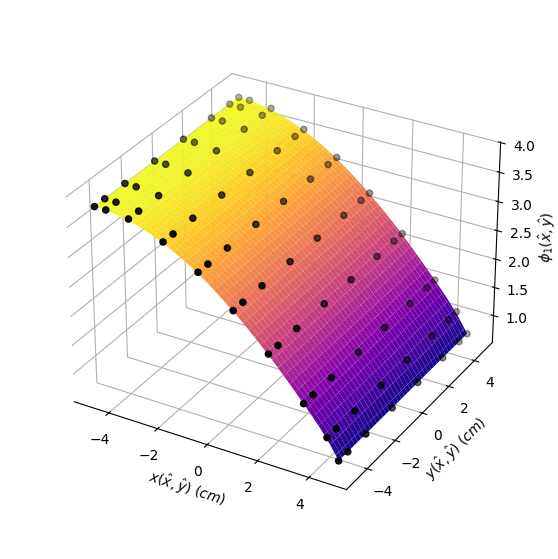

<Figure size 640x480 with 0 Axes>

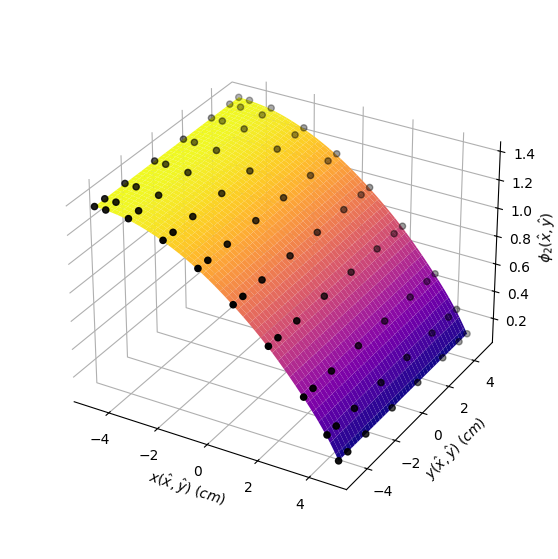

In [19]:
# Iterate through groups and plot
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_3d=True, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs/phi_{g + 1}_anisotropic.png", dpi=300)
    plt.show()